In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import convolution_matrix
from scipy.interpolate import interp1d

In [31]:
plt.rcParams['axes.labelpad'] = 0
plt.rcParams['figure.figsize'] = [6, 4]
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.xmargin'] = 0
plt.rcParams['axes.grid'] = True

In [ ]:
def least_square_deconvolve(h,x,y,lam=1e-3):
    """Function to perform least-square deconvolution of y with impulse response h
    """
    N = len(x)-len(h)+1
    H = convolution_matrix(h,N)
    M = np.dot(H.T,H) + lam*np.eye(N)
    return np.linalg.solve(M,np.dot(H.T,y))

def laser_impulse_response(fname, dt=0.05):
    """Function for extracting the laser pusle shape (time step dt is in ns)
    """
    arr = np.loadtxt(fname, skiprows=1, delimiter=',')
    order = np.argsort(arr[:,0])
    arr = arr[order,:]
    tl = arr[:,0]*1e-9
    pl = arr[:,1]
    t_interp = np.arange(0.5,2.5,dt)*1e-9
    f = interp1d(tl,pl,kind='linear')
    h = f(t_interp)
    h = np.flip(h)
    mask = h > 0.1
    t_interp = t_interp[mask]
    h = h[mask]
    return h / h.sum()

In [ ]:
# Read the data into a pd array
data = pd.read_csv('min_gate_measurement.csv')
data.head()

,Laser delay,Gate width,Counts
0,14.0,0.0,-3637.0
1,14.0,-0.1,-3797.0
2,14.0,3.0,58619.0
3,14.0,2.9,50041.0
4,14.0,2.8,43018.0


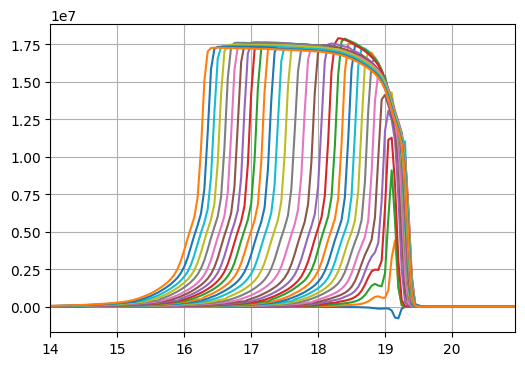

In [ ]:
# Make a pivot table
pivot = data.pivot(index='Laser delay', columns='Gate width', values='Counts')

# Extract laser delays
laser_delay = pivot.index.to_numpy()

# Get the laser pulse shape
h = laser_impulse_response(".\\laser_236mW.csv")

# Plot the gates
for gw in pivot.columns:
    # Gate form measurements
    gate = pivot[gw].to_numpy()
    # Deconvolution with laser pulse
    gate_deconv = least_square_deconvolve(h, laser_delay, gate, lam=0)
    # Plot
    plt.plot(laser_delay, gate, label=f"{gw:.1f}ns")
    #plt.plot(gate_deconv)